In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('Height-Weight Data.csv')
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
3496,69.296830,185.649086
3497,70.542201,210.198845
3498,73.912549,202.429960
3499,67.396021,144.277671


In [3]:
df.shape

(3501, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3501 entries, 0 to 3500
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  3501 non-null   float64
 1   Weight  3501 non-null   float64
dtypes: float64(2)
memory usage: 54.8 KB


In [5]:
df.isna().sum()

Height    0
Weight    0
dtype: int64

In [6]:
df.duplicated().sum()

0

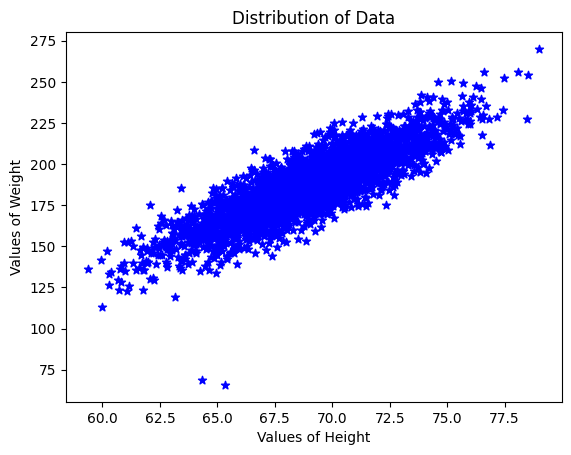

In [7]:
plt.scatter(df.Height, df.Weight, marker = '*', color = 'b')
plt.xlabel('Values of Height')
plt.ylabel('Values of Weight')
plt.title("Distribution of Data")
plt.show()

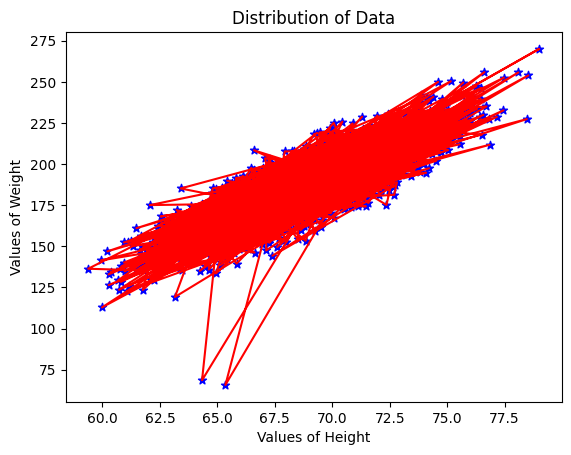

In [8]:
plt.scatter(df.Height, df.Weight, marker = '*', color = 'b')
plt.plot(df.Height, df.Weight, color = 'r')

plt.xlabel('Values of Height')
plt.ylabel('Values of Weight')
plt.title("Distribution of Data")
plt.show()

In [9]:
# Data Split
x = df.drop('Weight', axis = 1)
y = df[['Weight']]

In [10]:
x.head()

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796


In [11]:
y.head()

,Weight
0,241.893563
1,162.310473
2,212.740856
3,220.042470
4,206.349801


In [12]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size = 0.2, random_state = 42)


In [13]:
print(f'Shape of XTRAIN data: {xtrain.shape}')
print(f'Shape of YTRAIN data: {ytrain.shape}')
print(f'Shape of XTEST data: {xtest.shape}')
print(f'Shape of YTEST data: {ytest.shape}')

Shape of XTRAIN data: (2800, 1)
Shape of YTRAIN data: (2800, 1)
Shape of XTEST data: (701, 1)
Shape of YTEST data: (701, 1)


In [14]:
# Apply Linear Model
lr = LinearRegression()
lr.fit(xtrain, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
lr.score(xtrain, ytrain)

0.728885573697805

In [16]:
pred = lr.predict(xtest)
pred

array([[194.52602871],
       [176.32221443],
       [187.47569079],
       [235.28479353],
       [208.55066489],
       [188.65262141],
       [175.7815701 ],
       [185.78481771],
       [173.36073152],
       [202.75084787],
       [174.60458851],
       [218.38085184],
       [201.04996482],
       [197.93188467],
       [182.77830568],
       [176.85410589],
       [202.8203235 ],
       [200.51903044],
       [174.19532494],
       [185.6276918 ],
       [178.87851946],
       [165.69822081],
       [171.96478941],
       [177.26568654],
       [188.00332531],
       [175.87446611],
       [190.31072367],
       [182.86506281],
       [179.50428904],
       [163.93926807],
       [170.69319143],
       [197.17335484],
       [171.52507998],
       [188.04079205],
       [200.6829025 ],
       [189.44894806],
       [167.1960159 ],
       [202.30641997],
       [172.72262624],
       [169.58152465],
       [199.39304483],
       [167.75318095],
       [181.3692217 ],
       [211

In [17]:
# Model Evaluation

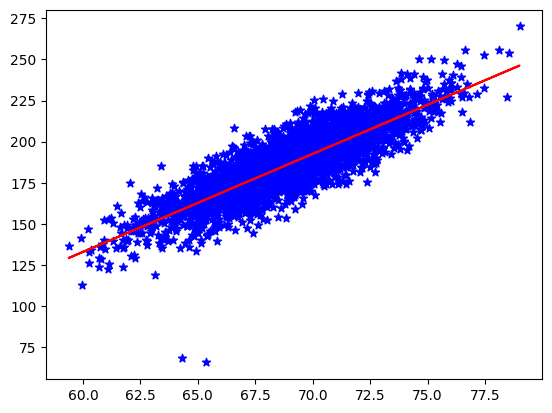

In [18]:
# Visualization: Entire Dataset
plt.scatter(x,y,marker = '*',color = 'b')
plt.plot(x,lr.predict(x),color = 'r')
plt.show()

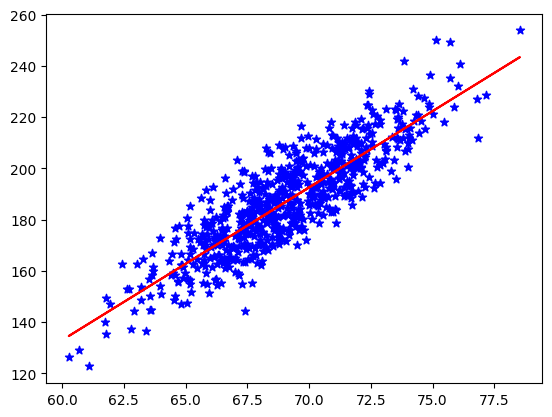

In [19]:
# Visualization: Test Data Only
plt.scatter(xtest,ytest,marker = '*',color = 'b')
plt.plot(xtest,lr.predict(xtest),color = 'r')
plt.show()

In [20]:
mse = mean_squared_error(ytest,pred)
mse

97.21750513299327

In [21]:
rmse = np.sqrt(mse)
mae = mean_absolute_error(ytest,pred)
r2 = r2_score(ytest,pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

RMSE: 9.8598937688493
MAE: 8.040126312816263
R2 Score: 0.7461790585161445


In [22]:
# Linear Regression with Gradient Descent

In [28]:
import numpy as np

x = np.array(x).reshape(-1)
y = np.array(y).reshape(-1)

m = 0
c = 0
l = 0.0001
n = len(x)
iterations = 1000

for i in range(iterations):
    pred = (m * x) + c
    
    der_m = (-2/n) * np.sum(x * (y - pred))
    der_c = (-2/n) * np.sum(y - pred)
    
    m = m - l * der_m
    c = c - l * der_c
    
    if i % 100 == 0:
        cost = (1/n) * np.sum((y - pred)**2)
        print(f"Iter {i}: m={m}, c={c}, cost={cost}")

ValueError: operands could not be broadcast together with shapes (200,) (3501,) 